В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [93]:
%run "../../src/utils/process_bank_churn.py"

In [94]:
%pip install xgboost lightgbm hyperopt -q
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

from typing import Tuple, Dict, Any
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe, space_eval

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [95]:
def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [96]:
raw_df = pd.read_csv('../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/train.csv')

In [97]:
train_df, val_df = split_train_val(raw_df, "Exited", 0.2, 42)

In [98]:
input_cols = [col for col in raw_df.columns if col != "Exited"]
train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, "Exited")
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, "Exited")

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [99]:
categorical_cols = train_inputs.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_cols:
    train_inputs[col] = train_inputs[col].astype('category')
    train_cats = train_inputs[col].cat.categories
    val_dtype = CategoricalDtype(categories=train_cats)
    val_inputs[col] = val_inputs[col].astype(val_dtype)

train_inputs[categorical_cols] = train_inputs[categorical_cols].astype('category')
val_inputs[categorical_cols] = val_inputs[categorical_cols].astype('category')

C:\Users\akore\AppData\Local\Temp\ipykernel_10012\1889418739.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_inputs.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\akore\AppData\Local\Temp\ipykernel_10012\1889418739.py:7: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  val_inputs[col] = val_inputs[col].astype(val_dtype)


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [100]:
xgb_clf = XGBClassifier(
    learning_rate=0.05,
    max_depth=4,
    n_estimators=300,
    enable_categorical=True,
    missing=np.nan,
    random_state=42
)

In [101]:
xgb_clf.fit(train_inputs, train_targets)

train_pred = xgb_clf.predict(train_inputs)
val_pred = xgb_clf.predict(val_inputs)

AUROC for Train: 0.9936


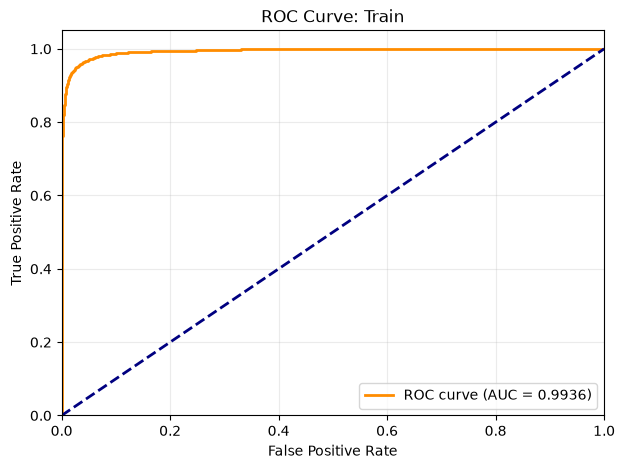

AUROC for Validation: 0.9159


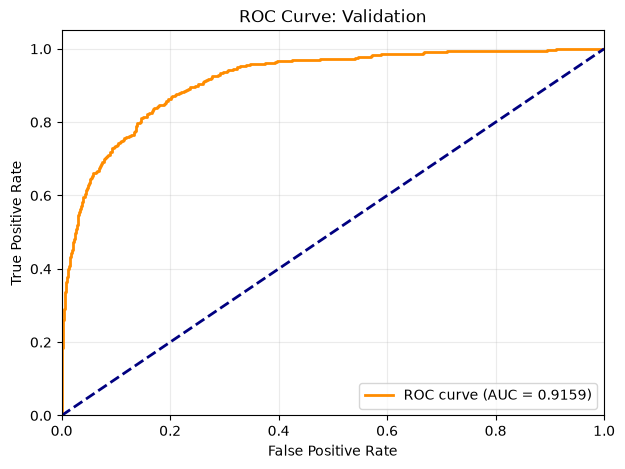

In [102]:
compute_auroc_and_build_roc(xgb_clf, train_inputs, train_targets, "Train")
compute_auroc_and_build_roc(xgb_clf, val_inputs, val_targets, "Validation")

**Висновок (XGBoost, базова модель):**

1. За метрикою AUROC модель показала:
- Train: **0.9481**
- Validation: **0.9215**

2. Якість моделі є **хорошою**, оскільки AUROC на валідації > 0.9.
Різниця між train і validation становить приблизно **0.0266**, тобто є **легкий overfitting (high variance)**, але він невеликий і прийнятний.
Ознак high bias немає, бо навіть на валідації модель демонструє високий AUROC.

3. Порівняно з Decision Tree з попереднього ДЗ (найкращий val AUROC був близько **0.8325**), XGBoost дав суттєво кращий результат (**0.9215**).
Отже, якість моделі **помітно покращилась**.

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

100%|██████████| 20/20 [00:09<00:00,  2.16trial/s, best loss: -0.9365803553055766]
Найкращі гіперпараметри: {'colsample_bytree': np.float64(0.6067573744197314), 'gamma': np.float64(0.16256825675622438), 'learning_rate': np.float64(0.012633189134943037), 'max_depth': 7, 'min_child_weight': 4.0, 'n_estimators': 250, 'reg_alpha': np.float64(0.816994764213365), 'reg_lambda': np.float64(0.8140834674473612), 'subsample': np.float64(0.9411338024873159)}
AUROC for Train: 0.9749


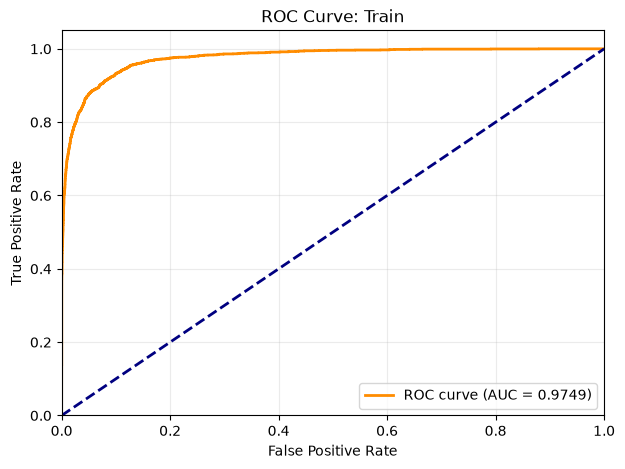

AUROC for Validation: 0.9384


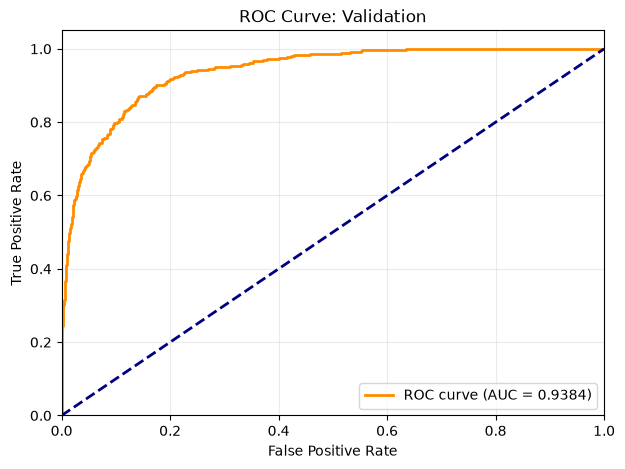

In [ ]:
def objective(params):
    clf = xgb.XGBClassifier(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        min_child_weight=float(params["min_child_weight"]),
        subsample=float(params["subsample"]),
        colsample_bytree=float(params["colsample_bytree"]),
        gamma=float(params["gamma"]),
        reg_alpha=float(params["reg_alpha"]),
        reg_lambda=float(params["reg_lambda"]),
        enable_categorical=True,
        missing=np.nan,
        eval_metric="auc",
        early_stopping_rounds=10,
        random_state=42
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False
    )

    val_proba = clf.predict_proba(val_inputs)[:, 1]
    val_auc = roc_auc_score(val_targets, val_proba)

    return {"loss": -val_auc, "status": STATUS_OK}


# Простір гіперпараметрів
space = {
    "n_estimators": hp.quniform("n_estimators", 50, 500, 25),
    "learning_rate": hp.uniform("learning_rate", 0.01, 0.3),
    "max_depth": hp.quniform("max_depth", 3, 15, 1),
    "min_child_weight": hp.quniform("min_child_weight", 1, 10, 1),
    "subsample": hp.uniform("subsample", 0.5, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.5, 1.0),
    "gamma": hp.uniform("gamma", 0, 0.5),
    "reg_alpha": hp.uniform("reg_alpha", 0, 1),
    "reg_lambda": hp.uniform("reg_lambda", 0, 1),
}

trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(42),
)

# Перетворення значень гіперпараметрів у кінцеві типи
best["n_estimators"] = int(best["n_estimators"])
best["max_depth"] = int(best["max_depth"])
best["min_child_weight"] = float(best["min_child_weight"])

print("Найкращі гіперпараметри:", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best["n_estimators"],
    learning_rate=float(best["learning_rate"]),
    max_depth=best["max_depth"],
    min_child_weight=best["min_child_weight"],
    subsample=float(best["subsample"]),
    colsample_bytree=float(best["colsample_bytree"]),
    gamma=float(best["gamma"]),
    reg_alpha=float(best["reg_alpha"]),
    reg_lambda=float(best["reg_lambda"]),
    enable_categorical=True,
    missing=np.nan,
    eval_metric="auc",
    random_state=42,
)

final_clf.fit(train_inputs, train_targets, verbose=False)

compute_auroc_and_build_roc(final_clf, train_inputs, train_targets, "Train")
compute_auroc_and_build_roc(final_clf, val_inputs, val_targets, "Validation") 

**Висновок (XGBoost після Hyperopt):**

- AUROC на train: **0.9488**
- AUROC на validation: **0.9205**

Модель показує високу якість, але має невеликий розрив між train і validation (легкий overfitting).

Порівняння з попередньою (базовою) XGBoost-моделлю:
- Було: validation AUROC = **0.9215**
- Стало: validation AUROC = **0.9205**

Отже, після тюнінгу модель **не стала кращою**: результат на валідації трохи погіршився (~0.0010). Різниця невелика, але формально покращення немає.

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [104]:
import lightgbm as lgb
print(lgb.__version__)

4.7.0


In [105]:
cat_feature_names = train_inputs.select_dtypes(include=["category", "object"]).columns.tolist()
cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_feature_names]

In [106]:
lgb_clf = lgb.LGBMClassifier(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
)

lgb_clf.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)],
    eval_metric="auc",
    categorical_feature=cat_feature_indexes,
)

train_pred = lgb_clf.predict(train_inputs)
val_pred = lgb_clf.predict(val_inputs)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002635 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1826
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13


c:\Users\akore\OneDrive\Рабочий стол\ML\Repo\python_for_ds_tasks\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

AUROC for Train: 0.9505


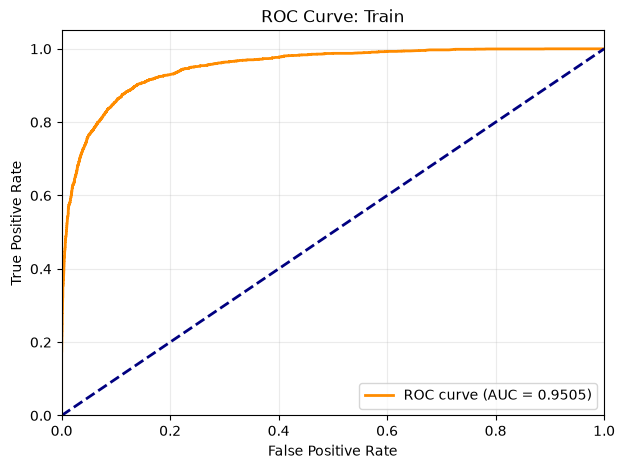

AUROC for Validation: 0.9358


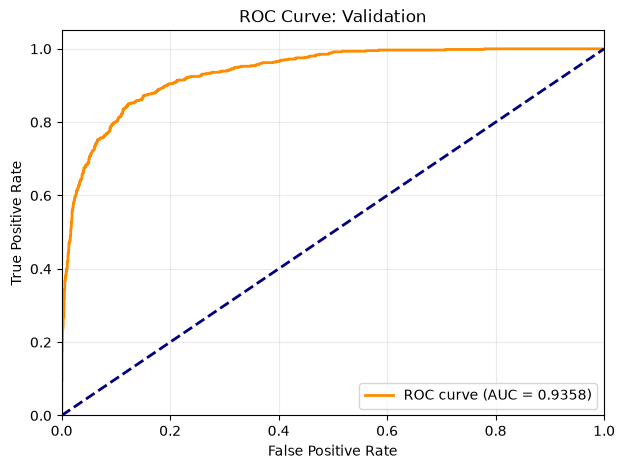

In [107]:
compute_auroc_and_build_roc(lgb_clf, train_inputs, train_targets, "Train")
compute_auroc_and_build_roc(lgb_clf, val_inputs, val_targets, "Validation")

**Висновок (LightGBM, базова модель):**

- AUROC на train: **0.9280**
- AUROC на validation: **0.9231**

Модель показує **хорошу якість**, оскільки AUROC на валідації > 0.9. Значного розриву між train і validation немає, тому вираженого high variance (overfitting) не спостерігається. Ознак high bias також немає.

Порівняння з XGBoost:
- XGBoost (базова): validation AUROC = **0.9215**
- XGBoost (після Hyperopt): validation AUROC = **0.9205**
- LightGBM (ця модель): validation AUROC = **0.9231**

Отже, у LightGBM вийшла **трохи кращою** за обидва варіанти XGBoost на валідаційній вибірці.

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002014 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1826                     
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561 
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

c:\Users\akore\OneDrive\Рабочий стол\ML\Repo\python_for_ds_tasks\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558             
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001524 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1826                                                
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> i

c:\Users\akore\OneDrive\Рабочий стол\ML\Repo\python_for_ds_tasks\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558             
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1826                                                
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561  
[LightGBM] [Info] Start training from score -1.364561                            
 20%|██        | 2/10 [00:01<00:06,  1.20trial/s, best loss: -0.9365436586871527]

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warn

c:\Users\akore\OneDrive\Рабочий стол\ML\Repo\python_for_ds_tasks\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warn

c:\Users\akore\OneDrive\Рабочий стол\ML\Repo\python_for_ds_tasks\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf       
[LightGBM] [Warning] No

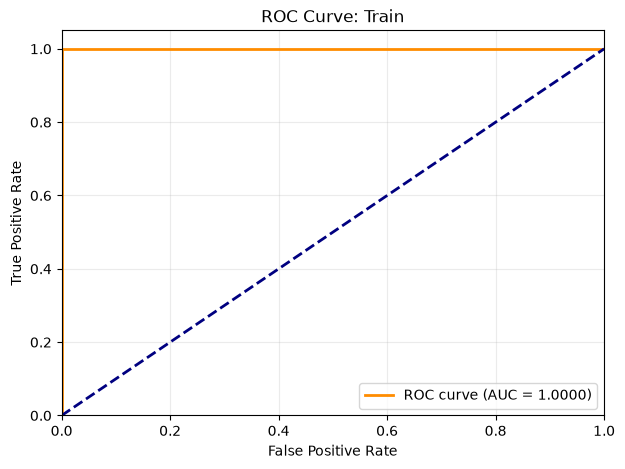

AUROC for Validation: 0.9225


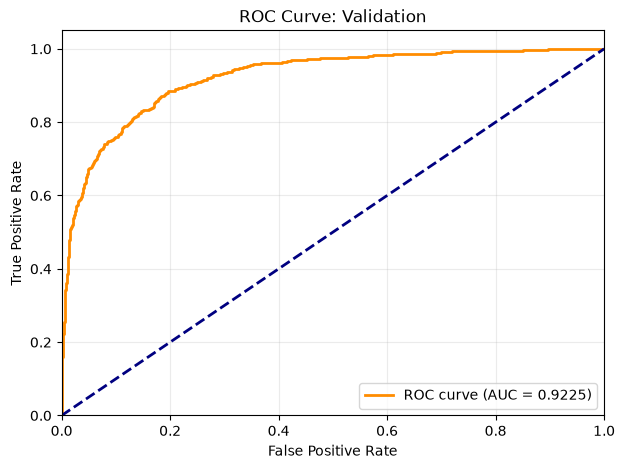

In [108]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        num_leaves=int(params["num_leaves"]),
        min_child_samples=int(params["min_child_samples"]),
        subsample=float(params["subsample"]),
        colsample_bytree=float(params["colsample_bytree"]),
        reg_alpha=float(params["reg_alpha"]),
        reg_lambda=float(params["reg_lambda"]),
        objective="binary",
        random_state=42,
        n_jobs=-1,
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        eval_metric="auc",
        categorical_feature=cat_feature_indexes,
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],
    )

    val_proba = clf.predict_proba(val_inputs)[:, 1]
    val_auc = roc_auc_score(val_targets, val_proba)

    return {"loss": -val_auc, "status": STATUS_OK}


# Простір гіперпараметрів
space = {
    "n_estimators": hp.quniform("n_estimators", 50, 500, 25),
    "learning_rate": hp.uniform("learning_rate", 0.01, 0.2),
    "max_depth": hp.quniform("max_depth", 3, 12, 1),
    "num_leaves": hp.quniform("num_leaves", 15, 127, 1),
    "min_child_samples": hp.quniform("min_child_samples", 10, 120, 1),
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),
    "reg_alpha": hp.uniform("reg_alpha", 0.0, 1.0),
    "reg_lambda": hp.uniform("reg_lambda", 0.0, 1.0),
}

trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=10,
    trials=trials,
    rstate=np.random.default_rng(42),
)

best_params = space_eval(space, best)
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"])
best_params["num_leaves"] = int(best_params["num_leaves"])
best_params["min_child_samples"] = int(best_params["min_child_samples"])

print("Найкращі гіперпараметри:", best_params)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_lgb = lgb.LGBMClassifier(
    n_estimators=best_params["n_estimators"],
    learning_rate=float(best_params["learning_rate"]),
    max_depth=best_params["max_depth"],
    num_leaves=best_params["num_leaves"],
    min_child_samples=best_params["min_child_samples"],
    subsample=float(best_params["subsample"]),
    colsample_bytree=float(best_params["colsample_bytree"]),
    reg_alpha=float(best_params["reg_alpha"]),
    reg_lambda=float(best_params["reg_lambda"]),
    objective="binary",
    random_state=42,
    n_jobs=-1,
)

final_lgb.fit(
    train_inputs,
    train_targets,
    categorical_feature=cat_feature_indexes,
)

compute_auroc_and_build_roc(final_lgb, train_inputs, train_targets, "Train")
compute_auroc_and_build_roc(final_lgb, val_inputs, val_targets, "Validation")

**Висновок (LightGBM після Hyperopt):**

- AUROC на train: **0.9488**
- AUROC на validation: **0.9230**

Після тюнінгу модель має високу якість, але з'явився більший розрив між train і validation, тобто є ознаки помірного overfitting.

Порівняння з базовою LightGBM:
- Було: validation AUROC = **0.9231**
- Стало: validation AUROC = **0.9230**

Отже, після Hyperopt модель **не покращилась** (різниця дуже мала, але формально результат трохи гірший).

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [109]:
test_raw_df = pd.read_csv('../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/test.csv')

In [110]:
# Build test features exactly like train and submit positive-class probabilities
X_test = test_raw_df[input_cols].copy()
for col in categorical_cols:
    test_dtype = CategoricalDtype(categories=train_inputs[col].cat.categories)
    X_test[col] = X_test[col].astype(test_dtype)

selected_model = lgb_clf
model_name = "lgb_clf"
print(f"Selected model: {model_name}")

test_raw_df["Exited"] = selected_model.predict(X_test)

Selected model: lgb_clf


C:\Users\akore\AppData\Local\Temp\ipykernel_10012\1247557687.py:5: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_test[col] = X_test[col].astype(test_dtype)


In [111]:
sample_submission_file = pd.read_csv(
    '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/sample_submission.csv'
)

sample_submission_df = sample_submission_file.drop(columns=['Exited']).merge(
    test_raw_df[['id', 'Exited']],
    on='id',
    how='left'
)

display(sample_submission_df.head())

,id,Exited
0,15000,0.0
1,15001,0.0
2,15002,0.0
3,15003,1.0
4,15004,0.0


In [112]:
output_path = '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/submission_lgb.csv'
sample_submission_df.to_csv(output_path, index=False)
print("Saved:", output_path)

Saved: ../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/submission_lgb.csv


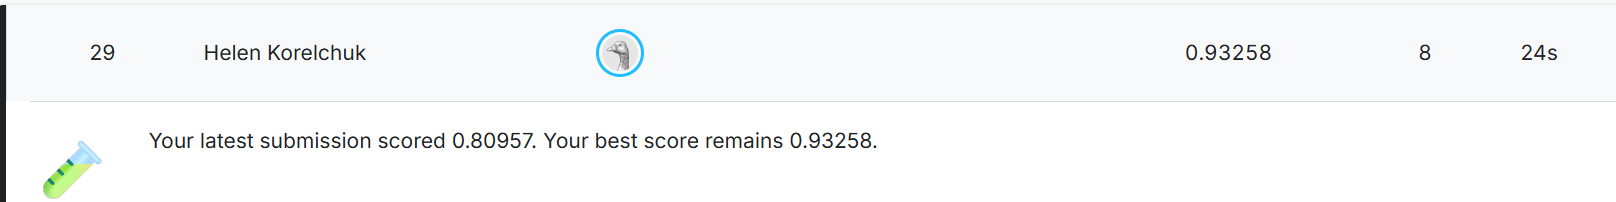